In [371]:
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [372]:
# BASE_DIR = Path("../assets/experiments_old/2026-03-12_15-18-43__nice_variant")
BASE_DIR = Path(r"../assets/experiments/error_new2/2026-03-18_18-09-30")
# BASE_DIR = Path("../assets/experiments/2026-03-11_15-09-57")
# BASE_DIR = Path("../assets/experiments/2026-03-11_10-48-53__5-15_secs")

BALANCER_DIR = BASE_DIR / "baseline"
REPL_NO_ADAPT_DIR = BASE_DIR / "non_adaptive"
REPL_ADAPT_DIR = BASE_DIR / "adaptive"

print(BASE_DIR)

..\assets\experiments\error_new2\2026-03-18_18-09-30


In [373]:
def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [374]:
def extract_method(data):
    factors = data["factors"]

    balancer = factors.get("balancer")
    replication = factors.get("replication")
    adaptive = factors.get("adaptive")

    if replication:
        return f"{balancer} | {replication} | {'adaptive' if adaptive else 'no_adaptive'}"

    return f"{balancer} | no_replication"

In [375]:
def flatten_requests(data, method, group):
    rows = []

    for req in data["requests"]:

        upstream = req.get("upstream", {})
        signals = req.get("signals", {})

        sockets = upstream.get("sockets", [])
        winner = upstream.get("winner_socket")

        if sockets:
            replicas = len(sockets)
        else:
            replicas = 1

        rows.append({
            "method": method,
            "group": group,

            "req_id": req["req_id"],
            "endpoint": req["endpoint"],

            "latency_ms": req["latency_ms"],
            "status": req["status"],
            "ok": req["ok"],

            "error_kind": req.get("error_kind"),
            "error": req.get("error"),

            "winner_socket": winner,
            "backend_port": signals.get("port"),

            "replicas": replicas,

            "cpu_util": signals.get("cpu_util"),
            "mem_util": signals.get("mem_util"),
            "cpu_burn": signals.get("cpu_burn"),
            "mem_burn": signals.get("mem_burn"),
        })

    return pd.DataFrame(rows)

In [376]:
def load_folder(folder, group):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        method = extract_method(data)

        df = flatten_requests(data, method, group)

        dfs.append(df)

    return dfs


dfs = []

dfs += load_folder(BALANCER_DIR, "balancer_only")
dfs += load_folder(REPL_NO_ADAPT_DIR, "replication_no_adaptive")
dfs += load_folder(REPL_ADAPT_DIR, "replication_adaptive")

df = pd.concat(dfs, ignore_index=True)

df.head()

,method,group,req_id,endpoint,latency_ms,status,ok,error_kind,error,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,airm | no_replication,balancer_only,req-0,cpu?seconds=2.0&fail_rate=0.02&slow_rate=0.03&...,2180.4865,200,True,None,None,GQW_8004,8004.0,1,43.1,24.0,True,None
1,airm | no_replication,balancer_only,req-1,cpu?seconds=3.0&fail_rate=0.02&slow_rate=0.03&...,3265.4627,200,True,None,None,GQW_8004,8004.0,1,42.1,24.7,True,None
2,airm | no_replication,balancer_only,req-2,cpu?seconds=2.0&fail_rate=0.02&slow_rate=0.03&...,2107.5237,200,True,None,None,GQW5_8003,8003.0,1,53.0,24.3,True,None
3,airm | no_replication,balancer_only,req-3,cpu?seconds=4.0&fail_rate=0.02&slow_rate=0.03&...,4821.5152,200,True,None,None,GQW9_8004,8004.0,1,43.7,24.7,True,None
4,airm | no_replication,balancer_only,req-4,cpu?seconds=2.0&fail_rate=0.02&slow_rate=0.03&...,2190.5688,200,True,None,None,GQW9_8004,8004.0,1,46.3,24.3,True,None


In [377]:
def p50(x):
    return np.percentile(x, 50)


def p95(x):
    return np.percentile(x, 95)


def p99(x):
    return np.percentile(x, 99)

# Latency

In [378]:
latency_stats = (
    df
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

latency_stats

,mean,p50,p95,p99
method,,,,
topsis | no_replication,4073.050755,3307.55700,8473.501850,11899.614187
topsis | hedged | no_adaptive,4124.927200,3353.12815,8393.411465,13983.363713
airm | no_replication,4146.960279,3356.02810,8631.742465,13244.085278
airm | hedged | no_adaptive,4164.414344,3373.09310,8407.454790,12837.005198


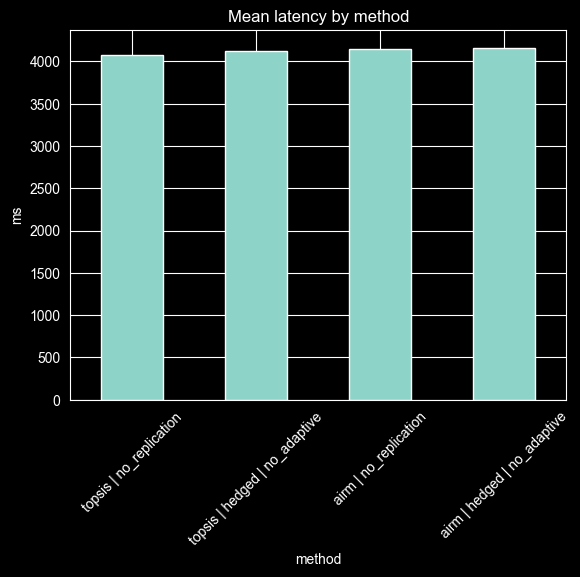

In [379]:
latency_stats["mean"].plot(kind="bar")

plt.title("Mean latency by method")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

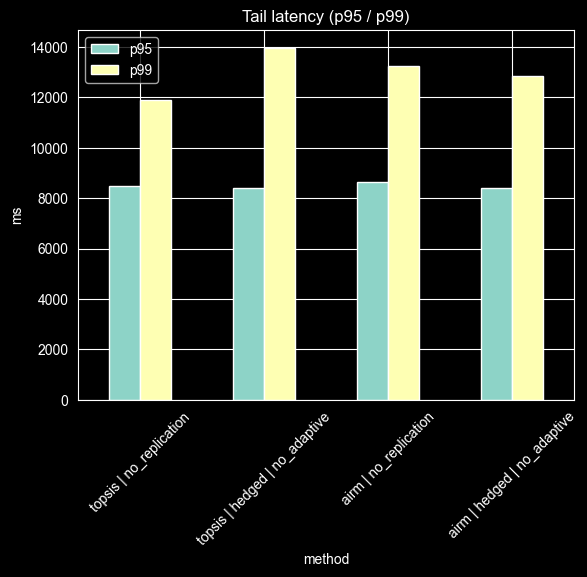

In [380]:
latency_stats[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency (p95 / p99)")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

# WA

In [381]:
wa_stats = (
    df
    .groupby("method")["replicas"]
    .agg(
        mean="mean",
        p95=p95,
        max="max"
    )
    .sort_values("mean")
)

wa_stats

,mean,p95,max
method,,,
airm | no_replication,1.000000,1.0,1
topsis | no_replication,1.000000,1.0,1
topsis | hedged | no_adaptive,1.026333,1.0,2
airm | hedged | no_adaptive,1.028333,1.0,2


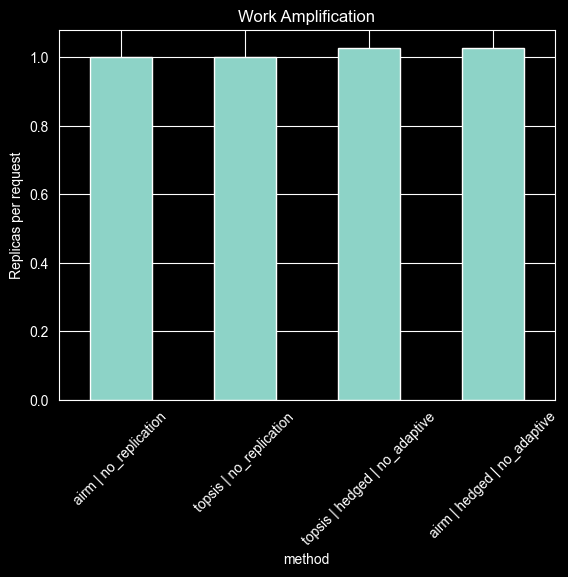

In [382]:
wa_stats["mean"].plot(kind="bar")

plt.title("Work Amplification")
plt.ylabel("Replicas per request")

plt.xticks(rotation=45)

plt.show()

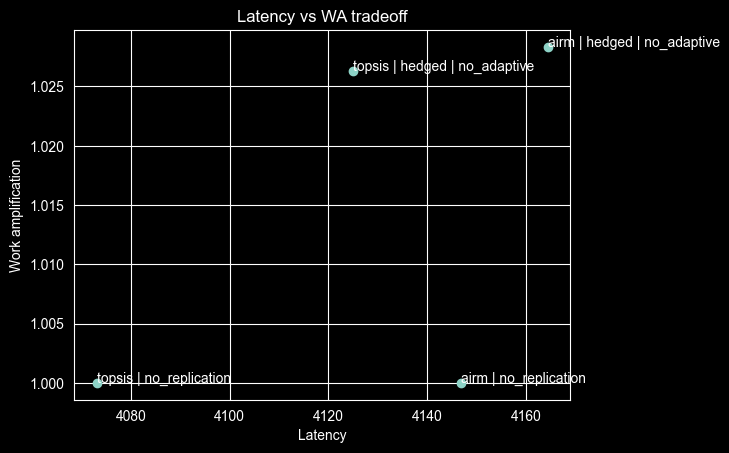

In [383]:
tradeoff = latency_stats.merge(
    wa_stats,
    left_index=True,
    right_index=True
)

plt.scatter(tradeoff["mean_x"], tradeoff["mean_y"])

for name, row in tradeoff.iterrows():
    plt.text(row["mean_x"], row["mean_y"], name)

plt.xlabel("Latency")
plt.ylabel("Work amplification")

plt.title("Latency vs WA tradeoff")

plt.show()

# CPU / MEM

In [384]:
socket_dist = (
    df
    .groupby(["method", "winner_socket"])
    .size()
    .reset_index(name="count")
)

socket_dist.head()

,method,winner_socket,count
0,airm | hedged | no_adaptive,,33
1,airm | hedged | no_adaptive,192.168.68.54:8001,92
2,airm | hedged | no_adaptive,192.168.68.54:8002,13
3,airm | hedged | no_adaptive,192.168.68.54:8003,12
4,airm | hedged | no_adaptive,192.168.68.54:8004,65


In [385]:
balance = (
    socket_dist
    .groupby("method")["count"]
    .agg(
        mean="mean",
        std="std"
    )
)

balance["cv"] = balance["std"] / balance["mean"]

balance.sort_values("cv")

,mean,std,cv
method,,,
airm | no_replication,46.616667,25.716243,0.551653
topsis | no_replication,46.550000,26.520491,0.569721
topsis | hedged | no_adaptive,25.741071,20.740241,0.805726
airm | hedged | no_adaptive,25.184211,21.125653,0.838845


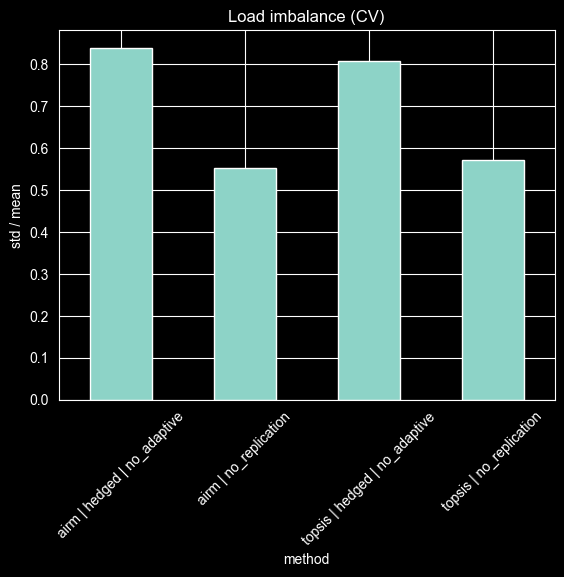

In [386]:
balance["cv"].plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [387]:
df["algorithm"] = df["method"].str.split(" | ").str[0]

compare = (
    df.groupby(["algorithm", "group"])["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
    .unstack("group")
)

compare

mean                                   p95  \
group     balancer_only replication_no_adaptive balancer_only   
algorithm                                                       
airm        4146.960279             4164.414344   8631.742465   
topsis      4073.050755             4124.927200   8473.501850   

                                            p99                          
group     replication_no_adaptive balancer_only replication_no_adaptive  
algorithm                                                                
airm                  8407.454790  13244.085278            12837.005198  
topsis                8393.411465  11899.614187            13983.363713

In [388]:
improvement = pd.DataFrame({
    "mean_improvement_%": (
            (compare["mean"]["balancer_only"] - compare["mean"]["replication_no_adaptive"])
            / compare["mean"]["balancer_only"] * 100
    ),
    "p95_improvement_%": (
            (compare["p95"]["balancer_only"] - compare["p95"]["replication_no_adaptive"])
            / compare["p95"]["balancer_only"] * 100
    ),
    "p99_improvement_%": (
            (compare["p99"]["balancer_only"] - compare["p99"]["replication_no_adaptive"])
            / compare["p99"]["balancer_only"] * 100
    ),
})

print("Replication improvement per algorithm (%):")
print(improvement.sort_values("p99_improvement_%", ascending=False))

Replication improvement per algorithm (%):
           mean_improvement_%  p95_improvement_%  p99_improvement_%
algorithm                                                          
airm                -0.420888           2.598406           3.073675
topsis              -1.273651           0.945186         -17.511068


In [389]:
adaptive_gain = pd.DataFrame({

    # replication vs baseline
    "replication_vs_baseline_mean_%": (
            (compare["mean"]["balancer_only"] - compare["mean"]["replication_no_adaptive"])
            / compare["mean"]["balancer_only"] * 100
    ),
    "replication_vs_baseline_p95_%": (
            (compare["p95"]["balancer_only"] - compare["p95"]["replication_no_adaptive"])
            / compare["p95"]["balancer_only"] * 100
    ),
    "replication_vs_baseline_p99_%": (
            (compare["p99"]["balancer_only"] - compare["p99"]["replication_no_adaptive"])
            / compare["p99"]["balancer_only"] * 100
    ),

    # adaptive vs non-adaptive replication
    "adaptive_vs_nonadaptive_mean_%": (
            (compare["mean"]["replication_no_adaptive"] - compare["mean"]["replication_adaptive"])
            / compare["mean"]["replication_no_adaptive"] * 100
    ),
    "adaptive_vs_nonadaptive_p95_%": (
            (compare["p95"]["replication_no_adaptive"] - compare["p95"]["replication_adaptive"])
            / compare["p95"]["replication_no_adaptive"] * 100
    ),
    "adaptive_vs_nonadaptive_p99_%": (
            (compare["p99"]["replication_no_adaptive"] - compare["p99"]["replication_adaptive"])
            / compare["p99"]["replication_no_adaptive"] * 100
    ),

    # adaptive vs baseline (итоговый эффект)
    "adaptive_vs_baseline_mean_%": (
            (compare["mean"]["balancer_only"] - compare["mean"]["replication_adaptive"])
            / compare["mean"]["balancer_only"] * 100
    ),
    "adaptive_vs_baseline_p95_%": (
            (compare["p95"]["balancer_only"] - compare["p95"]["replication_adaptive"])
            / compare["p95"]["balancer_only"] * 100
    ),
    "adaptive_vs_baseline_p99_%": (
            (compare["p99"]["balancer_only"] - compare["p99"]["replication_adaptive"])
            / compare["p99"]["balancer_only"] * 100
    ),
})

adaptive_gain = adaptive_gain.round(2)

print("Replication and adaptive improvements (%):")
print(adaptive_gain.sort_values("adaptive_vs_baseline_p99_%", ascending=False))

adaptive_gain.sort_values("adaptive_vs_baseline_p99_%", ascending=False)

KeyError: 'replication_adaptive'

In [ ]:
fig, ax = plt.subplots(figsize=(14,7))

adaptive_gain.plot(kind="bar", ax=ax)

ax.set_title("Replication impact on latency")
ax.set_ylabel("% improvement")

plt.show()

# Выгода адаптивности

In [ ]:
wa_group = (
    df
    .groupby("group")["replicas"]
    .mean()
)

wa_group

In [ ]:
adaptive_gain_ = (
                        (wa_group["replication_no_adaptive"]
                         - wa_group["replication_adaptive"])

                        / wa_group["replication_no_adaptive"]

                ) * 100

print("Adaptive WA reduction:", adaptive_gain_)

In [ ]:
wa_group.plot(kind="bar")

plt.title("Adaptive replication effect on WA")

plt.ylabel("WA")

plt.show()

# CPU vs MEM Latency

In [ ]:
df["is_cpu"] = df["endpoint"].str.startswith("cpu")

lat_cpu_mem = (

    df
    .groupby(["method", "is_cpu"])["latency_ms"]
    .mean()
    .unstack()
)

lat_cpu_mem

In [ ]:
lat_cpu_mem.plot(kind="bar")

plt.title("CPU vs MEM latency")

plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [ ]:
best_mean = latency_stats["mean"].idxmin()
best_p95 = latency_stats["p95"].idxmin()
best_wa = wa_stats["mean"].idxmin()

print("Best mean latency:", best_mean)
print("Best p95 latency:", best_p95)
print("Best WA:", best_wa)

# Сравнение с HAProxy

In [ ]:
HAPROXY_DIR = Path("../assets/experiments_old/haproxy__1-4_secs")


def load_haproxy(folder):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        name = file.stem.replace("haproxy_", "")
        method = f"haproxy | {name}"

        rows = []

        for req in data["requests"]:
            upstream = req.get("upstream", {})
            signals = req.get("signals", {})

            winner = upstream.get("winner_socket")

            rows.append({
                "method": method,
                "group": "haproxy",

                "req_id": req["req_id"],
                "endpoint": req["endpoint"],

                "latency_ms": req["latency_ms"],
                "status": req["status"],
                "ok": req["ok"],

                "winner_socket": winner,
                "replicas": 1,

                "cpu_util": signals.get("cpu_util"),
                "mem_util": signals.get("mem_util"),
                "cpu_burn": signals.get("cpu_burn"),
                "mem_burn": signals.get("mem_burn"),
            })

        dfs.append(pd.DataFrame(rows))

    return dfs


haproxy_dfs = load_haproxy(HAPROXY_DIR)

df_haproxy = pd.concat(haproxy_dfs, ignore_index=True)

df_haproxy.head()

In [ ]:
df_all = pd.concat([df, df_haproxy], ignore_index=True)
df_all["backend"] = df_all["backend_port"].fillna(df_all["winner_socket"])
df_all.head()

In [ ]:
df_balancing_only = df_all[
    df_all["group"].isin(["balancer_only", "haproxy"])
].copy()

print("Methods in df_balancing_only:")
print(sorted(df_balancing_only["method"].unique()))

df_balancing_only["backend"] = (
    df_balancing_only["backend_port"]
    .astype("string")
    .fillna(df_balancing_only["winner_socket"])
)

df_balancing_only["backend_clean"] = (
    df_balancing_only["backend"]
    .astype(str)
    .str.split("_")
    .str[-1]
    .str.replace("p", "", regex=False)
)

print(df_balancing_only[["backend", "backend_clean"]].head(20))

## Сравнение HAProxy алгоритмов

In [ ]:
lat_compare = (
    df_balancing_only
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

lat_compare

In [ ]:
lat_compare["mean"].plot(kind="bar")

plt.title("Latency comparison (no replication)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [ ]:
lat_compare[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency comparison (p95 / p99)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

## Балансировка нагрузки HAProxy

In [ ]:
socket_counts_balancing = (
    df_balancing_only
    .dropna(subset=["backend_clean"])
    .groupby(["method", "backend_clean"])
    .size()
    .reset_index(name="count")
)

print("Methods in socket_counts_balancing:")
print(sorted(socket_counts_balancing["method"].unique()))

In [ ]:
imbalance = socket_counts_balancing.groupby("method")["count"].agg(
    mean="mean",
    std="std"
)

imbalance["cv"] = imbalance["std"] / imbalance["mean"]

imbalance.sort_values("cv")

In [ ]:
order = imbalance["cv"].sort_values().index

socket_counts_balancing["method"] = pd.Categorical(
    socket_counts_balancing["method"],
    categories=order,
    ordered=True
)

In [ ]:
imbalance["cv"].sort_values().plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [ ]:
socket_counts_balancing["normalized"] = (
        socket_counts_balancing["count"] /
        socket_counts_balancing.groupby("method")["count"].transform("mean")
)

plt.figure(figsize=(12, 6))

socket_counts_balancing.boxplot(
    column="normalized",
    by="method",
    rot=45,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="yellow"),
)

plt.title("Normalized load distribution")
plt.suptitle("")
plt.ylabel("Load / ideal load")
plt.ylim(0.25, 1.5)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

rows = []

for method, group in socket_counts_balancing.groupby("method"):
    counts = group["count"].values
    share = counts / counts.sum()

    rows.append({
        "method": method,
        "min": share.min(),
        "median": np.median(share),
        "max": share.max()
    })

share_df = pd.DataFrame(rows).set_index("method")

share_df.plot(kind="bar", figsize=(10,6))

plt.axhline(share_df["median"].mean(), linestyle="--")

plt.ylabel("Share of requests")
plt.title("Load share spread per algorithm")

plt.show()

In [ ]:
rows = []

n_servers = socket_counts_balancing["backend_clean"].nunique()
ideal = 1 / n_servers

for method, group in socket_counts_balancing.groupby("method"):

    counts = group["count"].values
    share = counts / counts.sum()

    deviation = np.abs(share - ideal)

    rows.append({
        "method": method,
        "mean_deviation": deviation.mean(),
        "max_deviation": deviation.max()
    })

dev_df = pd.DataFrame(rows).set_index("method")

dev_df.sort_values("mean_deviation").plot(kind="bar", figsize=(10,6))

plt.ylabel("Deviation from ideal load")
plt.title("Load balancing fairness")

plt.show()

In [ ]:
lat_mean = (
    df_balancing_only
    .groupby("method")["latency_ms"]
    .mean()
)

tradeoff = pd.concat([lat_mean, imbalance["cv"]], axis=1)

plt.scatter(tradeoff["latency_ms"], tradeoff["cv"])

for name, row in tradeoff.iterrows():
    plt.text(row["latency_ms"], row["cv"], name)

plt.xlabel("Mean latency (ms)")
plt.ylabel("Load imbalance (CV)")

plt.title("Latency vs load imbalance (no replication)")

plt.show()

## Числовые сравнения

In [ ]:
lat_stats = (
    df_all
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
)

my_algorithms = lat_stats[
    lat_stats.index.str.contains("no_replication")
]

haproxy_algorithms = lat_stats[
    lat_stats.index.str.contains("haproxy")
]

best_my = my_algorithms.sort_values("mean").iloc[0]
best_haproxy = haproxy_algorithms.sort_values("mean").iloc[0]

best_my_name = my_algorithms.sort_values("mean").index[0]
best_haproxy_name = haproxy_algorithms.sort_values("mean").index[0]

print("Best my algorithm:", best_my_name)
print("Best haproxy algorithm:", best_haproxy_name)

In [ ]:
mean_gain = (best_haproxy["mean"] - best_my["mean"]) / best_haproxy["mean"] * 100
p50_gain = (best_haproxy["p50"] - best_my["p50"]) / best_haproxy["p50"] * 100
p95_gain = (best_haproxy["p95"] - best_my["p95"]) / best_haproxy["p95"] * 100
p99_gain = (best_haproxy["p99"] - best_my["p99"]) / best_haproxy["p99"] * 100

print("\nLatency improvement vs HAProxy round-robin:")

print(f"Mean latency improvement: {mean_gain:.2f}%")
print(f"P50 latency improvement: {p50_gain:.2f}%")
print(f"P95 latency improvement: {p95_gain:.2f}%")
print(f"P99 latency improvement: {p99_gain:.2f}%")

In [ ]:
imbalance = (
    socket_counts_balancing
    .groupby("method")["count"]
    .agg(mean="mean", std="std")
)

imbalance["cv"] = imbalance["std"] / imbalance["mean"]

my_imbalance = imbalance[
    imbalance.index.str.contains("no_replication")
]

haproxy_imbalance = imbalance[
    imbalance.index.str.contains("haproxy")
]
best_my_cv_name = my_imbalance["cv"].idxmin()
best_haproxy_cv_name = haproxy_imbalance["cv"].idxmin()

best_my_cv = imbalance.loc[best_my_cv_name, "cv"]
best_haproxy_cv = imbalance.loc[best_haproxy_cv_name, "cv"]

print("Best my algorithm (CV):", best_my_cv_name)
print("Best haproxy algorithm (CV):", best_haproxy_cv_name)

print("\nCV values:")
print("My algorithm CV:", best_my_cv)
print("HAProxy CV:", best_haproxy_cv)

cv_gain = (best_haproxy_cv - best_my_cv) / best_haproxy_cv * 100

print(f"\nLoad balance improvement: {cv_gain:.2f}%")

In [ ]:
imbalance.sort_values("cv")

# Сравнение ошибок

In [ ]:
error_stats = (
    df
    .groupby("method")["ok"]
    .agg(
        total="count",
        success="sum"
    )
)

error_stats["errors"] = error_stats["total"] - error_stats["success"]
error_stats["error_rate"] = error_stats["errors"] / error_stats["total"]

error_stats.sort_values("error_rate", ascending=False)

In [ ]:
error_by_group = (
    df
    .groupby("group")["ok"]
    .agg(
        total="count",
        success="sum"
    )
)

error_by_group["errors"] = error_by_group["total"] - error_by_group["success"]
error_by_group["error_rate"] = error_by_group["errors"] / error_by_group["total"]

error_by_group

In [ ]:
baseline_err = error_by_group.loc["balancer_only", "error_rate"]
rep_no_err = error_by_group.loc["replication_no_adaptive", "error_rate"]
rep_ad_err = error_by_group.loc["replication_adaptive", "error_rate"]

replication_gain = (baseline_err - rep_no_err) / baseline_err * 100
adaptive_gain = (rep_no_err - rep_ad_err) / rep_no_err * 100

print(f"Replication error reduction: {replication_gain:.2f}%")
print(f"Adaptive replication improvement: {adaptive_gain:.2f}%")

In [ ]:
error_by_group["error_rate"].plot(kind="bar")

plt.title("Error rate by experiment group")
plt.ylabel("Error rate")

plt.show()

In [ ]:
error_df = (
    df
    .groupby("error_kind")
    .size()
    .reset_index(name="count")
)

error_df["rate"] = error_df["count"] / len(df)

print(error_df.sort_values("count", ascending=False))

In [ ]:
error_kinds = (
    df
    .assign(error_kind=df["ok"].map({True: "none", False: "request_error"}))
    .groupby("error_kind")
    .size()
    .reset_index(name="count")
)

error_kinds["rate"] = error_kinds["count"] / len(df)

print(error_kinds.sort_values("count", ascending=False))

In [ ]:

error_status = (
    df
    .groupby("status")
    .size()
    .reset_index(name="count")
)

error_status["rate"] = error_status["count"] / len(df)

print(error_status.sort_values("count", ascending=False))

In [ ]:

error_status.set_index("status")["rate"].plot(kind="bar")

plt.title("Error rate by HTTP status")
plt.ylabel("Rate")

plt.show()

In [ ]:
baseline = df[df["group"] == "balancer_only"]

baseline["latency_ms"].describe(percentiles=[0.95,0.99])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- p99 latency ---
lat_by_group = (
    df.groupby("group")["latency_ms"]
    .apply(p99)
)

lat_by_group = lat_by_group.reindex([
    "balancer_only",
    "replication_no_adaptive",
    "replication_adaptive"
])

lat_by_group.plot(kind="bar", ax=axes[0])
axes[0].set_title("P99 задержка")
axes[0].set_ylabel("миллисекунды")
axes[0].set_xticklabels([
    "Балансировка",
    "С репликациями",
    "С адаптивными репликациями"
], rotation=20)

# начинаем ось не с нуля
axes[0].set_ylim(lat_by_group.min() * 0.95, lat_by_group.max() * 1.05)


# --- Work Amplification ---
wa_by_group = (
    df.groupby("group")["replicas"]
    .mean()
)

wa_by_group = wa_by_group.reindex([
    "replication_no_adaptive",
    "replication_adaptive"
])

wa_by_group.plot(kind="bar", ax=axes[1])
axes[1].set_title("Work amplification")
axes[1].set_ylabel("Количество репликаций на запрос")
axes[1].set_xticklabels([
    "С репликациями",
    "С адаптивными репликациями"
], rotation=20)

# начинаем ось не с нуля
axes[1].set_ylim(wa_by_group.min() * 0.9, wa_by_group.max() * 1.05)


plt.tight_layout()
plt.show()